# Using RaCo Keypoints for Matching with LightGlue

In this example we show how you can use RaCo's keypoints with descriptors from ALIKED with LightGlue for matching.

In [1]:
import torch
from lightglue import ALIKED, LightGlue

from raco import RaCo
from raco.utils import load_image, rbd

device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize the models
extractor = RaCo(max_num_keypoints=1024).eval().to(device)
descriptor = ALIKED().eval().to(device)
matcher = LightGlue(features="raco-aliked").eval().to(device)

[RaCo] Loaded weights from https://github.com/cvg/RaCo/releases/download/v1.0.0/raco.pth


In [2]:
image0 = load_image("assets/v_grace_1.ppm").to(device)
image1 = load_image("assets/v_grace_3.ppm").to(device)

# Extract and describe keypoints
feats0 = extractor.extract(image0)
feats0["descriptors"] = descriptor.describe(feats0["keypoints"], image0)
feats1 = extractor.extract(image1)
feats1["descriptors"] = descriptor.describe(feats1["keypoints"], image1)

# Match keypoints
matches01 = matcher({"image0": feats0, "image1": feats1})

feats0, feats1, matches01 = [
    rbd(x) for x in [feats0, feats1, matches01]
]  # remove batch dimension

# Extract matches
kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]
m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]

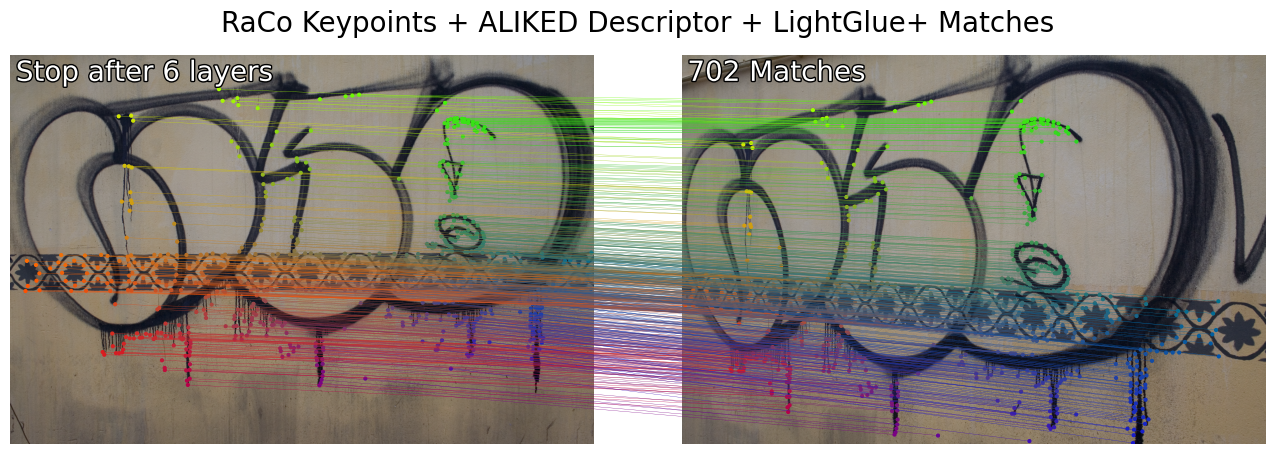

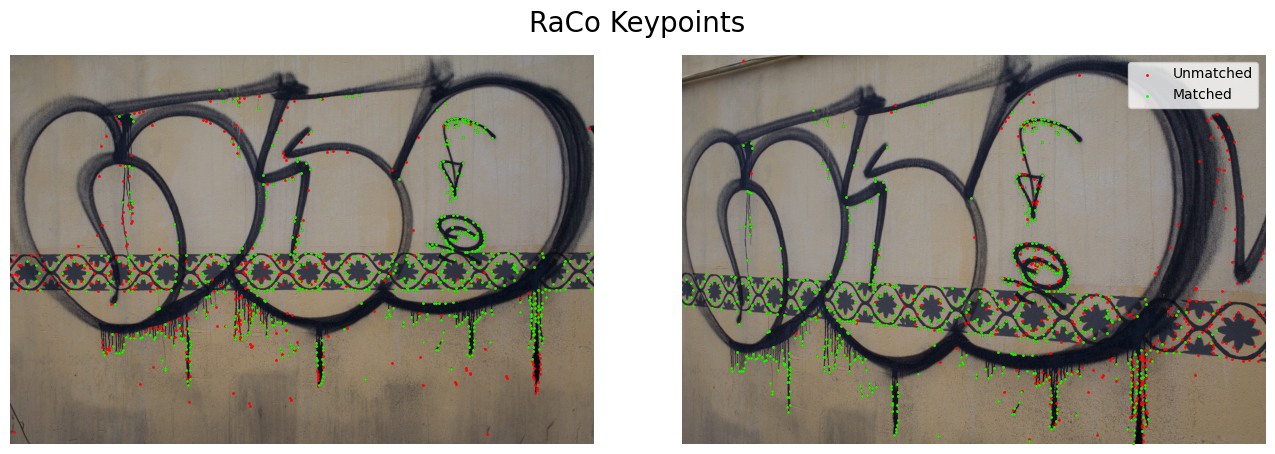

In [3]:
import matplotlib.pyplot as plt
from lightglue import viz2d

viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color=None, lw=0.2)
viz2d.add_text(0, f"Stop after {matches01['stop']} layers", fs=20)
viz2d.add_text(1, f"{len(m_kpts0)} Matches", fs=20)
plt.gcf().subplots_adjust(top=0.88)
plt.suptitle("RaCo Keypoints + ALIKED Descriptor + LightGlue+ Matches", fontsize=20)

viz2d.plot_images([image0, image1])
viz2d.plot_keypoints([kpts0, kpts1], colors="red")
viz2d.plot_keypoints([m_kpts0, m_kpts1], colors="lime")
plt.legend(["Unmatched", "Matched"], loc="upper right")
plt.gcf().subplots_adjust(top=0.88)
plt.suptitle("RaCo Keypoints", fontsize=20)
plt.show()